In [1]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, Flatten, Dense, Conv2D, MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import os
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load the reshaped datasets
X_train_resized = np.load('/content/drive/MyDrive/PHYSIODATA/X_train_resized.npy')
X_test_resized = np.load('/content/drive/MyDrive/PHYSIODATA/X_test_resized.npy')
y_train = np.load('/content/drive/MyDrive/PHYSIODATA/y_train_resized.npy')
y_test = np.load('/content/drive/MyDrive/PHYSIODATA/y_test_resized.npy')

In [4]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess_input

# Preprocess the data
X_train_resized = inception_preprocess_input(np.repeat(X_train_resized, 3, axis=-1))
X_test_resized = inception_preprocess_input(np.repeat(X_test_resized, 3, axis=-1))

In [5]:
# Define the InceptionV3 model
height, width, channels = 150, 150, 1
base_model_inception = InceptionV3(weights='imagenet', include_top=False, input_shape=(height, width, 3))
x = base_model_inception.output
x = Flatten()(x)
x = Dense(64, activation='relu')(x)
predictions = Dense(5, activation='softmax')(x)
model_inception = Model(inputs=base_model_inception.input, outputs=predictions)

# Freeze the base model layers
for layer in base_model_inception.layers:
    layer.trainable = False

# Compile the model
model_inception.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)
checkpoint_path = '/content/drive/MyDrive/PHYSIO2D/PHYSIOinception.h5'
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, mode='max')

87910968/87910968 [==============================] - 0s 0us/step


In [6]:
# Train and evaluate the model
history = model_inception.fit(
    X_train_resized, y_train,
    epochs=400,
    batch_size=64,
    validation_data=(X_test_resized, y_test),
    callbacks=[checkpoint , early_stopping]
)

train_accuracy = model_inception.evaluate(X_train_resized, y_train, verbose=0)[1]
test_accuracy = model_inception.evaluate(X_test_resized, y_test, verbose=0)[1]

print(f"Training Accuracy: {train_accuracy}, Test Accuracy: {test_accuracy}")

Epoch 1/400
140/140 [==============================] - ETA: 0s - loss: 1.0187 - accuracy: 0.5599

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


140/140 [==============================] - 16s 61ms/step - loss: 1.0187 - accuracy: 0.5599 - val_loss: 0.8935 - val_accuracy: 0.6109
Epoch 2/400
140/140 [==============================] - 3s 22ms/step - loss: 0.9108 - accuracy: 0.6020 - val_loss: 0.8707 - val_accuracy: 0.5993
Epoch 3/400
140/140 [==============================] - 4s 28ms/step - loss: 0.8560 - accuracy: 0.6251 - val_loss: 0.8163 - val_accuracy: 0.6534
Epoch 4/400
140/140 [==============================] - 4s 28ms/step - loss: 0.7881 - accuracy: 0.6587 - val_loss: 0.7422 - val_accuracy: 0.6817
Epoch 5/400
140/140 [==============================] - 3s 22ms/step - loss: 0.7500 - accuracy: 0.6795 - val_loss: 0.7644 - val_accuracy: 0.6690
Epoch 6/400
140/140 [==============================] - 4s 28ms/step - loss: 0.6957 - accuracy: 0.7100 - val_loss: 0.6664 - val_accuracy: 0.6933
Epoch 7/400
140/140 [==============================] - 4s 28ms/step - loss: 0.6449 - accuracy: 0.7306 - val_loss: 0.6293 - val_accuracy: 0.7726
Epo

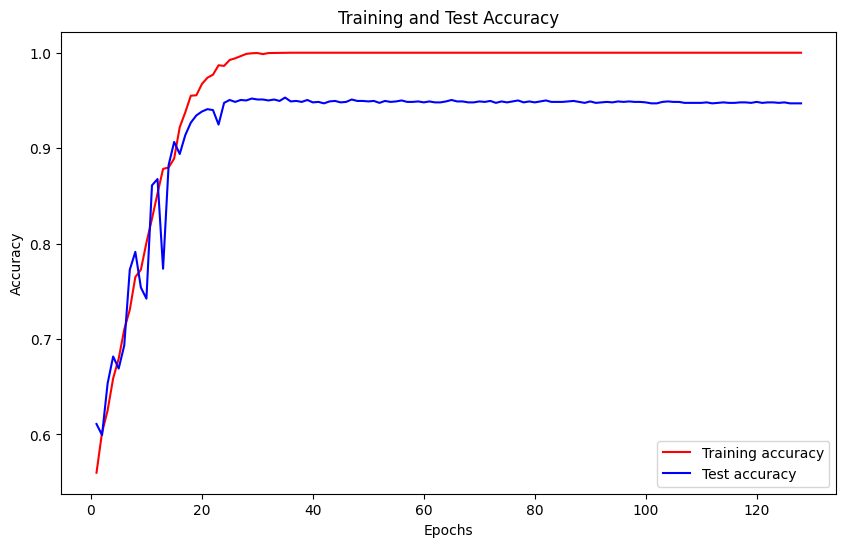

In [7]:
import matplotlib.pyplot as plt

# Plot training and validation accuracies over epochs

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(acc) + 1)  # Number of epochs


plt.figure(figsize=(10, 6))
plt.plot(epochs, acc, 'r', label='Training accuracy')  # 'bo' gives blue color and dot markers
plt.plot(epochs, val_acc, 'b', label='Test accuracy')   # 'b' gives solid blue line
plt.title('Training and Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [8]:
from tensorflow.keras.models import load_model
model_path = '/content/drive/MyDrive/PHYSIO2D/PHYSIOinception.h5'
loaded_model = load_model(model_path)

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# Generate predictions
y_pred = loaded_model.predict(X_test_resized)
y_pred_classes = np.argmax(y_pred, axis=1)

62/62 [==============================] - 2s 12ms/step


In [10]:
# Print classification report
class_report = classification_report(y_test, y_pred_classes)
print("\nClassification Report:\n", class_report)


Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.92      0.94       185
           1       0.95      0.97      0.96      1137
           2       0.94      0.93      0.94       627
           3       1.00      0.93      0.97        30

    accuracy                           0.95      1979
   macro avg       0.96      0.94      0.95      1979
weighted avg       0.95      0.95      0.95      1979



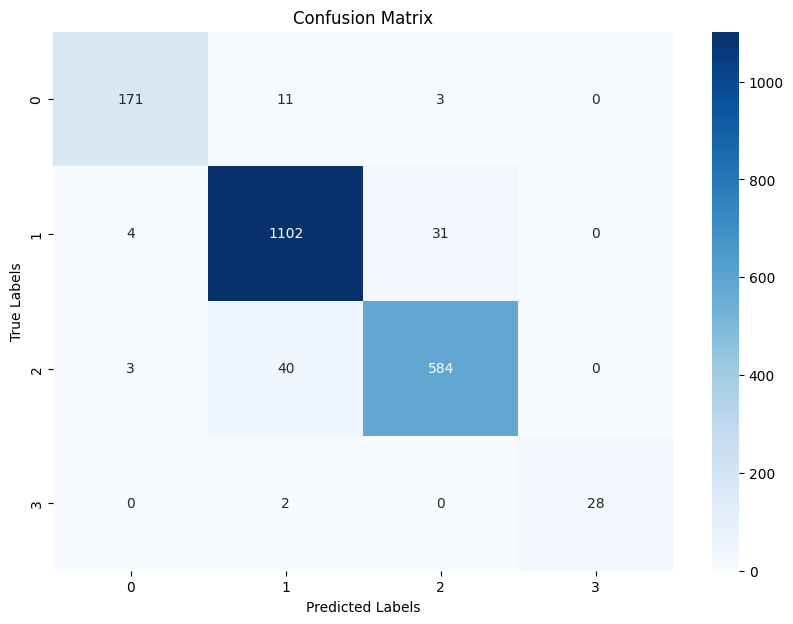

In [11]:
# Compute and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

62/62 [==============================] - 1s 12ms/step


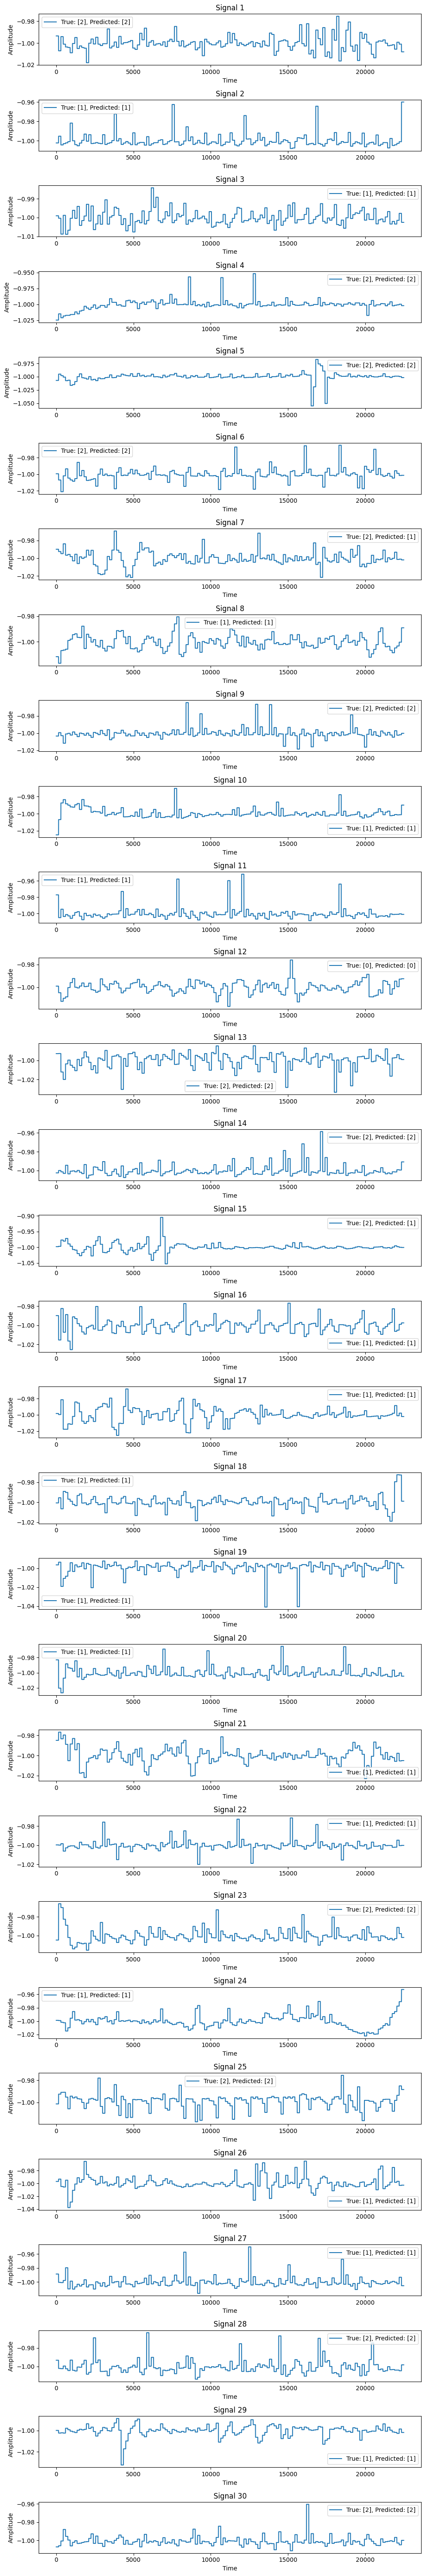

Correct Predictions: 1885
Incorrect Predictions: 94


In [12]:
# Plot sample signals with true and predicted labels, and display prediction accuracy
def plot_and_predict(X_test, y_test, model, num_samples=10, channel=0):

    # Ensure num_samples does not exceed length of X_test
    num_samples = min(num_samples, len(X_test))

    # Predict the labels
    predictions = model.predict(X_test)
    predicted_labels = np.argmax(predictions, axis=1)

    # Count correct and incorrect predictions
    correct = np.sum(predicted_labels == y_test)
    incorrect = len(y_test) - correct



    # Start plotting
    fig, axes = plt.subplots(num_samples, 1, figsize=(10, num_samples * 2))
    if num_samples == 1:
        axes = [axes]  # Make it iterable

    for i, ax in enumerate(axes):
        signal = X_test[i, :, :, channel].flatten()  # Flatten to 1D for plotting
        true_label = [y_test[i]]
        predicted_label = [predicted_labels[i]]
        ax.plot(signal, label=f'True: {true_label}, Predicted: {predicted_label}')
        ax.legend()
        ax.set_title(f'Signal {i+1}')
        ax.set_xlabel('Time')
        ax.set_ylabel('Amplitude')

    plt.tight_layout()
    plt.show()

    print(f"Correct Predictions: {correct}")
    print(f"Incorrect Predictions: {incorrect}")


plot_and_predict(X_test_resized, y_test, loaded_model, num_samples=30)